# AeroVision — Dataset EDA

Exploratory Data Analysis (EDA) do dataset Drone-Traffic.

**Objetivo:** analisar a distribuição das imagens, classes, instâncias e
anotações de segmentação antes do treinamento dos modelos.

Dataset:
- Drone-Traffic
- 1.319 imagens
- 4 classes de veículos
- Anotações de detecção e segmentação em formato COCO

In [2]:
!pip -q install pycocotools

In [3]:
import os
import json
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pycocotools.coco import COCO

Matplotlib is building the font cache; this may take a moment.


In [4]:
from pathlib import Path
import os

# Caminho do projeto AeroVision
PROJECT_DIR = Path.cwd().parent

print("Projeto:", PROJECT_DIR)

Projeto: c:\Users\jaysa.gabrielly\Documents\GitHub\AeroVision


In [5]:
DATASET_DIR = (
    PROJECT_DIR
    / "data"
    / "raw"
    / "Drone-Traffic.v1i.coco-segmentation"
)

print("Dataset:", DATASET_DIR)
print("Existe?", DATASET_DIR.exists())

Dataset: c:\Users\jaysa.gabrielly\Documents\GitHub\AeroVision\data\raw\Drone-Traffic.v1i.coco-segmentation
Existe? True


In [7]:
for split in ["train", "valid", "test"]:
    split_dir = DATASET_DIR / split

    print(f"\n[{split.upper()}]")
    print("Existe?", split_dir.exists())

    if split_dir.exists():
        print("Arquivos:", len(list(split_dir.iterdir())))


[TRAIN]
Existe? True
Arquivos: 951

[VALID]
Existe? True
Arquivos: 252

[TEST]
Existe? True
Arquivos: 119


In [8]:
for split in ["train", "valid", "test"]:
    split_dir = DATASET_DIR / split
    
    print(f"\n[{split.upper()}]")
    print("Diretório:", split_dir)
    
    if split_dir.exists():
        files = list(split_dir.iterdir())
        print("Arquivos:", len(files))
    else:
        print("ERRO: diretório não encontrado.")


[TRAIN]
Diretório: c:\Users\jaysa.gabrielly\Documents\GitHub\AeroVision\data\raw\Drone-Traffic.v1i.coco-segmentation\train
Arquivos: 951

[VALID]
Diretório: c:\Users\jaysa.gabrielly\Documents\GitHub\AeroVision\data\raw\Drone-Traffic.v1i.coco-segmentation\valid
Arquivos: 252

[TEST]
Diretório: c:\Users\jaysa.gabrielly\Documents\GitHub\AeroVision\data\raw\Drone-Traffic.v1i.coco-segmentation\test
Arquivos: 119


In [9]:
coco_data = {}

for split in ["train", "valid", "test"]:
    annotation_file = DATASET_DIR / split / "_annotations.coco.json"
    
    with open(annotation_file, "r", encoding="utf-8") as f:
        coco_data[split] = json.load(f)

    print(
        split,
        "→",
        len(coco_data[split]["images"]),
        "imagens |",
        len(coco_data[split]["annotations"]),
        "anotações"
    )

train → 950 imagens | 14229 anotações
valid → 251 imagens | 3839 anotações
test → 118 imagens | 1697 anotações


In [10]:
categories = coco_data["train"]["categories"]

print("Categorias encontradas:\n")

for category in categories:
    print(
        f"ID {category['id']}: "
        f"{category['name']} "
        f"(supercategoria: {category['supercategory']})"
    )

Categorias encontradas:

ID 0: Vehicles (supercategoria: none)
ID 1: bicycle (supercategoria: Vehicles)
ID 2: bus (supercategoria: Vehicles)
ID 3: car (supercategoria: Vehicles)
ID 4: lorry (supercategoria: Vehicles)


In [11]:
class_categories = [
    category
    for category in categories
    if category["name"] != "Vehicles"
]

CLASS_NAMES = {
    category["id"]: category["name"]
    for category in class_categories
}

CLASS_NAMES

{1: 'bicycle', 2: 'bus', 3: 'car', 4: 'lorry'}

In [12]:
summary = []

for split in ["train", "valid", "test"]:
    summary.append({
        "split": split,
        "images": len(coco_data[split]["images"]),
        "annotations": len(coco_data[split]["annotations"])
    })

summary_df = pd.DataFrame(summary)

summary_df

,split,images,annotations
0,train,950,14229
1,valid,251,3839
2,test,118,1697


In [13]:
print("Total de imagens:", summary_df["images"].sum())
print("Total de instâncias:", summary_df["annotations"].sum())

Total de imagens: 1319
Total de instâncias: 19765


In [14]:
class_counts = {}

for split in ["train", "valid", "test"]:
    annotations = coco_data[split]["annotations"]
    
    counter = Counter(
        ann["category_id"]
        for ann in annotations
        if ann["category_id"] in CLASS_NAMES
    )
    
    class_counts[split] = {
        CLASS_NAMES[class_id]: counter[class_id]
        for class_id in CLASS_NAMES
    }

class_distribution = pd.DataFrame(class_counts).T

class_distribution

,bicycle,bus,car,lorry
train,796,859,9410,3164
valid,226,249,2501,863
test,101,116,1100,380


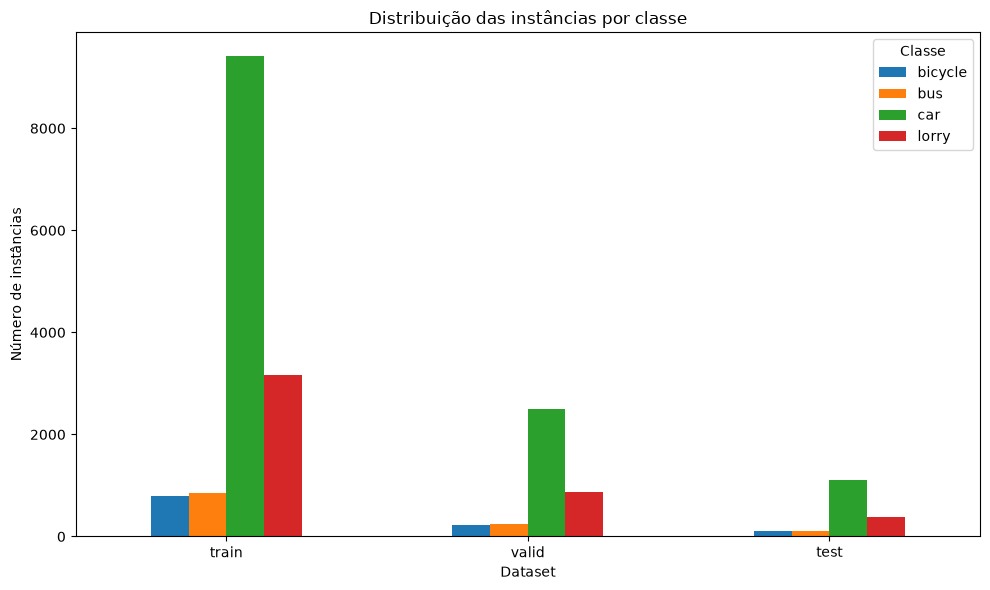

In [15]:
class_distribution.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribuição das instâncias por classe")
plt.xlabel("Dataset")
plt.ylabel("Número de instâncias")
plt.xticks(rotation=0)
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

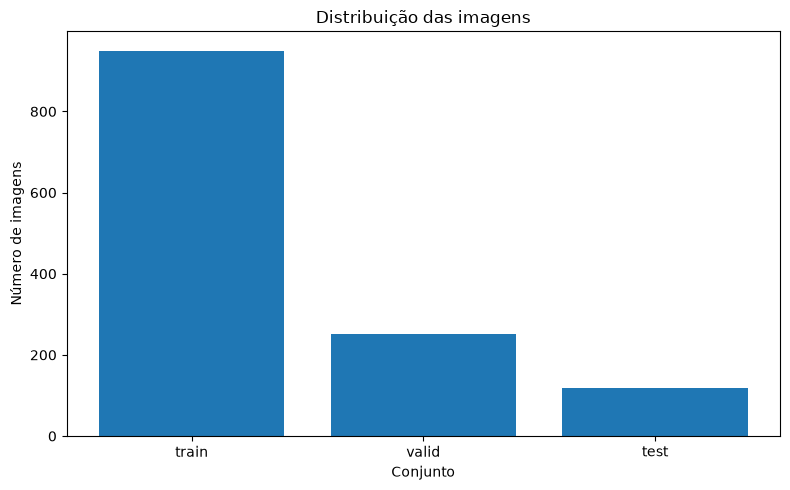

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["split"],
    summary_df["images"]
)

plt.title("Distribuição das imagens")
plt.xlabel("Conjunto")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

In [17]:
for split in ["train", "valid", "test"]:
    
    images = coco_data[split]["images"]
    annotations = coco_data[split]["annotations"]
    
    objects_per_image = Counter(
        ann["image_id"]
        for ann in annotations
        if ann["category_id"] in CLASS_NAMES
    )
    
    values = list(objects_per_image.values())
    
    print(
        f"{split}: "
        f"média = {np.mean(values):.2f} objetos/imagem | "
        f"mediana = {np.median(values):.0f}"
    )

train: média = 16.66 objetos/imagem | mediana = 17
valid: média = 16.91 objetos/imagem | mediana = 17
test: média = 16.48 objetos/imagem | mediana = 17


In [18]:
image_dimensions = []

for split in ["train", "valid", "test"]:
    
    for image_info in coco_data[split]["images"]:
        
        image_dimensions.append({
            "split": split,
            "width": image_info["width"],
            "height": image_info["height"]
        })

dimensions_df = pd.DataFrame(image_dimensions)

dimensions_df.head()

,split,width,height
0,train,416,416
1,train,416,416
2,train,416,416
3,train,416,416
4,train,416,416


In [19]:
dimensions_df.groupby(["width", "height"]).size().sort_values(
    ascending=False
).head(20)

width  height
416    416       1319
dtype: int64

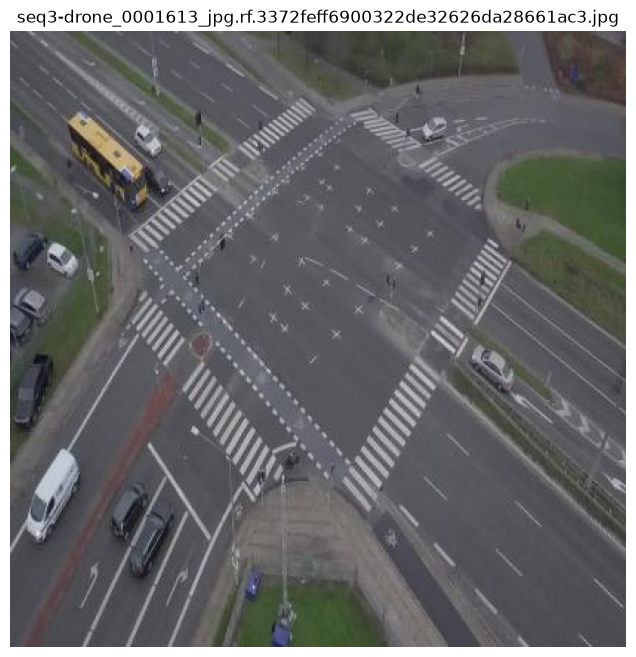

In [21]:
split = "train"

image_info = random.choice(coco_data[split]["images"])

image_path = DATASET_DIR / split / image_info["file_name"]

image = Image.open(image_path)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title(image_info["file_name"])
plt.show()

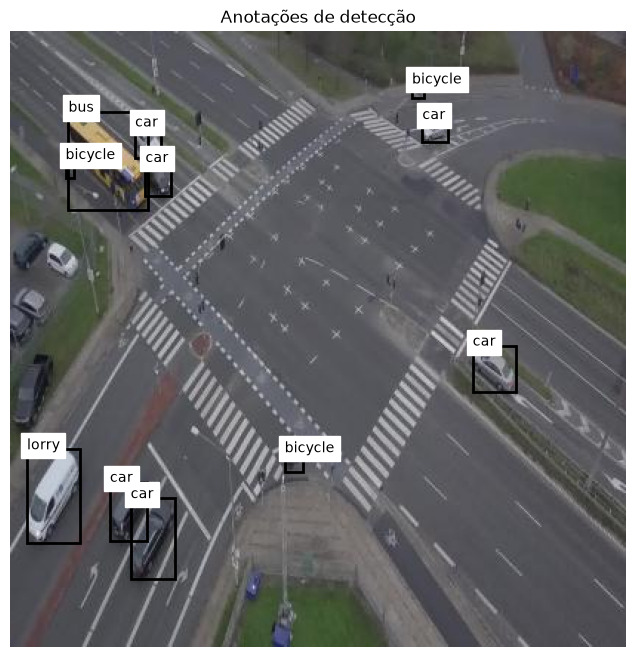

In [23]:
image_id = image_info["id"]

annotations = [
    ann
    for ann in coco_data[split]["annotations"]
    if ann["image_id"] == image_id
    and ann["category_id"] in CLASS_NAMES
]

plt.figure(figsize=(12, 8))
plt.imshow(image)

ax = plt.gca()

for ann in annotations:
    x, y, w, h = ann["bbox"]
    
    rect = plt.Rectangle(
        (x, y),
        w,
        h,
        fill=False,
        linewidth=2
    )
    
    ax.add_patch(rect)
    
    ax.text(
        x,
        y,
        CLASS_NAMES[ann["category_id"]],
        fontsize=10,
        backgroundcolor="white"
    )

plt.axis("off")
plt.title("Anotações de detecção")
plt.show()

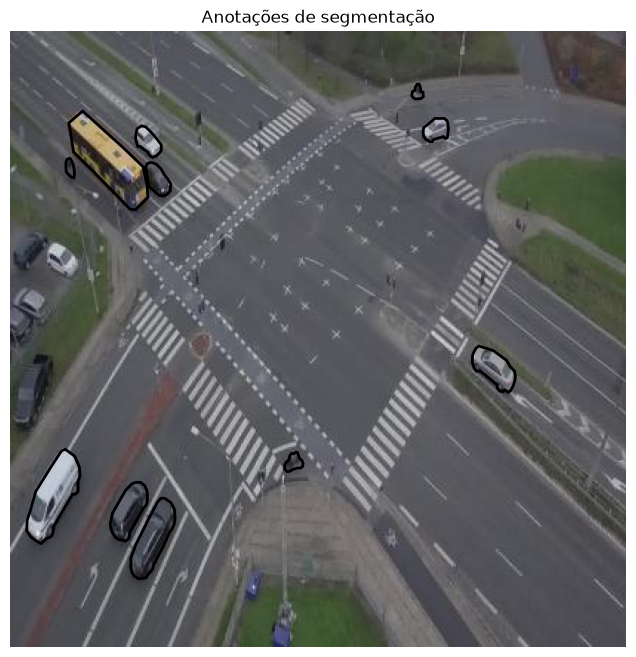

In [24]:
from matplotlib.patches import Polygon

plt.figure(figsize=(12, 8))
plt.imshow(image)

ax = plt.gca()

for ann in annotations:
    
    segmentation = ann.get("segmentation", [])
    
    if not segmentation:
        continue
    
    for polygon in segmentation:
        
        polygon = np.array(polygon).reshape(-1, 2)
        
        patch = Polygon(
            polygon,
            closed=True,
            fill=False,
            linewidth=2
        )
        
        ax.add_patch(patch)

plt.axis("off")
plt.title("Anotações de segmentação")
plt.show()

In [25]:
total_annotations = 0
annotations_without_segmentation = 0

for split in ["train", "valid", "test"]:
    
    for ann in coco_data[split]["annotations"]:
        
        if ann["category_id"] not in CLASS_NAMES:
            continue
        
        total_annotations += 1
        
        if not ann.get("segmentation"):
            annotations_without_segmentation += 1

print("Total de instâncias:", total_annotations)
print(
    "Sem segmentação:",
    annotations_without_segmentation
)

Total de instâncias: 19765
Sem segmentação: 0


In [26]:
used_categories = set()

for split in ["train", "valid", "test"]:
    for ann in coco_data[split]["annotations"]:
        used_categories.add(ann["category_id"])

print("IDs de categorias utilizados:")
print(sorted(used_categories))

print("\nClasses correspondentes:")

for category_id in sorted(used_categories):
    name = next(
        category["name"]
        for category in categories
        if category["id"] == category_id
    )
    
    print(category_id, "→", name)

IDs de categorias utilizados:
[1, 2, 3, 4]

Classes correspondentes:
1 → bicycle
2 → bus
3 → car
4 → lorry


In [28]:
RESULTS_DIR = PROJECT_DIR / "results" / "eda"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary_df.to_csv(
    RESULTS_DIR / "dataset_summary.csv",
    index=False
)

class_distribution.to_csv(
    RESULTS_DIR / "class_distribution.csv"
)

dimensions_df.to_csv(
    RESULTS_DIR / "image_dimensions.csv",
    index=False
)

print("Resultados salvos em:")
print(RESULTS_DIR)

Resultados salvos em:
c:\Users\jaysa.gabrielly\Documents\GitHub\AeroVision\results\eda


In [29]:
# Inspeção das segmentações COCO

segmentation_types = Counter()
num_polygons = []
empty_segmentations = 0

for split in ["train", "valid", "test"]:
    for annotation in coco_data[split]["annotations"]:
        segmentation = annotation.get("segmentation")

        if segmentation is None or segmentation == []:
            empty_segmentations += 1
            continue

        segmentation_types[type(segmentation).__name__] += 1

        if isinstance(segmentation, list):
            num_polygons.append(len(segmentation))

print("Tipos de segmentação encontrados:")
for seg_type, count in segmentation_types.items():
    print(f"  {seg_type}: {count}")

print()
print("Anotações sem segmentação:", empty_segmentations)

if num_polygons:
    print()
    print("Polígonos por anotação:")
    print("  Mínimo:", min(num_polygons))
    print("  Máximo:", max(num_polygons))
    print("  Média:", round(np.mean(num_polygons), 2))

Tipos de segmentação encontrados:
  list: 19765

Anotações sem segmentação: 0

Polígonos por anotação:
  Mínimo: 1
  Máximo: 1
  Média: 1.0
